Após a acurácia do modelo se manter, encotra-se uma opção que é definir melhor a classificação. Dado o crescimento de vendas em gadgets, caso e-waste esteja crescendo numa frequência menor, então o país obeteve um crescimento sujo. Caso contrário, verde.
Essa mudança foi necessária visto que variáveis de penetração não influenciam diretamente na média.

In [ ]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer




In [ ]:
df = pd.read_csv("Global_Tech_Gadget_Consumption.csv")

# Inspeção inicial
print("Dimensão da base:", df.shape)
print("\nColunas disponíveis:", df.columns.tolist())
print("\nVisualização das 5 primeiras linhas:")
print(df.head())

# Resumo estatístico
print("\nResumo estatístico:")
print(df.describe(include="all"))

Dimensão da base: (110, 9)

Colunas disponíveis: ['Country', 'Year', 'Smartphone Sales (Millions)', 'Laptop Shipments (Millions)', 'Gaming Console Adoption (%)', 'Smartwatch Penetration (%)', 'Average Consumer Spending on Gadgets ($)', 'E-Waste Generated (Metric Tons)', '5G Penetration Rate (%)']

Visualização das 5 primeiras linhas:
  Country  Year  Smartphone Sales (Millions)  Laptop Shipments (Millions)  \
0     USA  2015                       111.37                       123.63   
1     USA  2016                       224.65                        65.27   
2     USA  2017                       102.12                        26.75   
3     USA  2018                       148.10                       129.28   
4     USA  2019                        83.93                        97.81   

   Gaming Console Adoption (%)  Smartwatch Penetration (%)  \
0                        12.05                       14.49   
1                        12.92                        9.88   
2              

=== KNN (Millions) | Melhor conjunto (CV, F1 classe 1) ===
{'knn__n_neighbors': 11, 'knn__p': 1, 'knn__weights': 'distance'}

=== KNN (Millions) | Avaliação no TESTE ===
Accuracy: 0.3
Balanced Accuracy: 0.3
F1 (classe 1 - Verde): 0.46153846153846156
F1 (macro): 0.23076923076923078
AUC-ROC: 0.44

Relatório:
               precision    recall  f1-score   support

        Sujo       0.00      0.00      0.00         5
       Verde       0.38      0.60      0.46         5

    accuracy                           0.30        10
   macro avg       0.19      0.30      0.23        10
weighted avg       0.19      0.30      0.23        10

Matriz de Confusão:
 [[0 5]
 [2 3]]


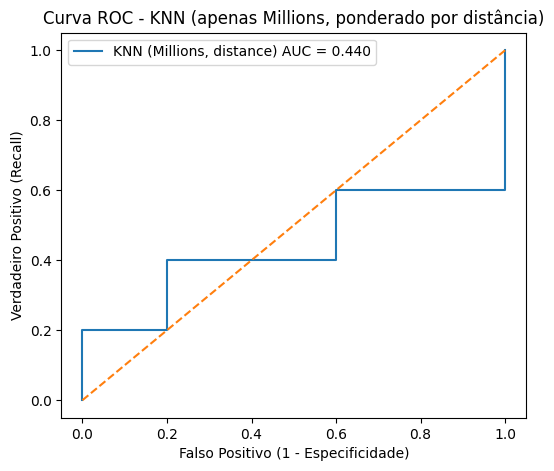

In [ ]:

# PREPROCESS (apenas variáveis em escala "Millions"

def preprocess_millions(df):
    # Ordenar por País e Ano
    df = df.sort_values(["Country","Year"]).copy()

    # Codificar país
    le = LabelEncoder()
    df["Country_Code"] = le.fit_transform(df["Country"])

    # Calcular deltas
    df["Delta_Spending"] = df.groupby("Country")["Average Consumer Spending on Gadgets ($)"].diff()
    df["Delta_Ewaste"]   = df.groupby("Country")["E-Waste Generated (Metric Tons)"].diff()

    # Criar classe alvo (regra: Verde=1 se ΔSpending>0 e ΔEwaste>0; Sujo=0 caso contrário)
    def classify_growth(row):
        if pd.notnull(row["Delta_Spending"]) and row["Delta_Spending"] > 0:
            return 1 if row["Delta_Ewaste"] > 0 else 0
        return None

    df["Sustentabilidade"] = df.apply(classify_growth, axis=1)
    df = df.dropna(subset=["Sustentabilidade"]).copy()
    df["Sustentabilidade"] = df["Sustentabilidade"].astype(int)

    # Features: só colunas em "Millions" + País/Ano (para contexto temporal/espacial)
    features = [
        "Smartphone Sales (Millions)",
        "Laptop Shipments (Millions)",  # opcional: comente esta linha se não quiser
        "Country_Code",
        "Year"
    ]

    X = df[features].copy()
    y = df["Sustentabilidade"].copy()
    return X, y
# KNN (só variáveis em "Millions") + GridSearchCV

# Pré-processamento alternativo
X, y = preprocess_millions(df)

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Pipeline: padronização + KNN
pipe_knn = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# Hiperparâmetros (já incluindo weights="distance")
param_grid_knn = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["distance"],   # força ponderamento
    "knn__p": [1, 2]                # Manhattan (p=1) ou Euclidiana (p=2)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_minority = make_scorer(f1_score, pos_label=1)

grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    scoring=f1_minority,
    cv=cv,
    n_jobs=-1,
    refit=True
)

# Treino
grid_knn.fit(x_train, y_train)
best_knn = grid_knn.best_estimator_
print("=== KNN (Millions) | Melhor conjunto (CV, F1 classe 1) ===")
print(grid_knn.best_params_)

# Avaliação no teste
y_pred_knn = best_knn.predict(x_test)
y_prob_knn = best_knn.predict_proba(x_test)[:, 1]

print("\n=== KNN (Millions) | Avaliação no TESTE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_knn))
print("F1 (classe 1 - Verde):", f1_score(y_test, y_pred_knn, pos_label=1))
print("F1 (macro):", f1_score(y_test, y_pred_knn, average="macro"))
print("AUC-ROC:", roc_auc_score(y_test, y_prob_knn))
print("\nRelatório:\n", classification_report(y_test, y_pred_knn, target_names=["Sujo","Verde"]))
print("Matriz de Confusão:\n", confusion_matrix(y_test, y_pred_knn, labels=[0,1]))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"KNN (Millions, distance) AUC = {roc_auc_score(y_test, y_prob_knn):.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("Falso Positivo (1 - Especificidade)")
plt.ylabel("Verdadeiro Positivo (Recall)")
plt.title("Curva ROC - KNN (apenas Millions, ponderado por distância)")
plt.legend()
plt.show()



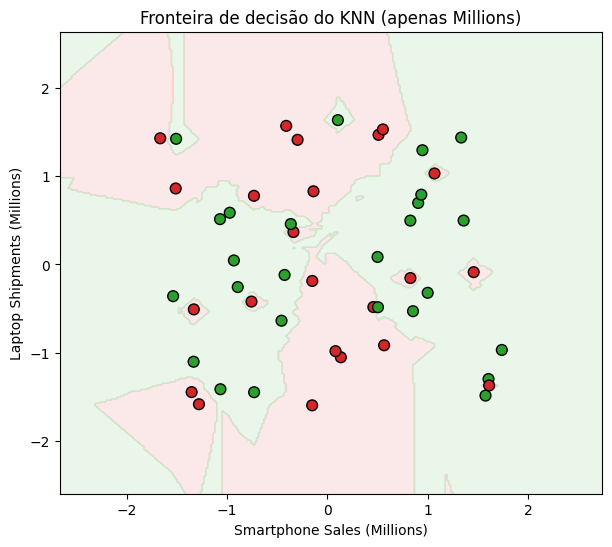

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Selecionar apenas duas features para visualização
feat_x = "Smartphone Sales (Millions)"
feat_y = "Laptop Shipments (Millions)"

X2 = X[[feat_x, feat_y]].to_numpy()
y2 = y.to_numpy()

# Normalização
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X2s = scaler.fit_transform(X2)

# KNN já treinado com melhores parâmetros
best_knn_vis = KNeighborsClassifier(
    n_neighbors=grid_knn.best_params_["knn__n_neighbors"],
    weights="distance",
    p=grid_knn.best_params_["knn__p"]
)
best_knn_vis.fit(X2s, y2)

# Grade para decisão
x_min, x_max = X2s[:, 0].min() - 1, X2s[:, 0].max() + 1
y_min, y_max = X2s[:, 1].min() - 1, X2s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

Z = best_knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
cmap_bg = ListedColormap(["#f7c6c6", "#c9eac9"])  # fundo (sujo/verede)
cmap_pts = ListedColormap(["#d62728", "#2ca02c"])  # pontos

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
plt.scatter(X2s[:, 0], X2s[:, 1], c=y2, cmap=cmap_pts, edgecolor="k", s=60)
plt.xlabel(feat_x)
plt.ylabel(feat_y)
plt.title("Fronteira de decisão do KNN (apenas Millions)")
plt.show()


Nota-se que o modelo está com overfitting, ou seja, é preciso olhar para raíz da questão.Antes, tentar ajustar o valor de k para entender os padrões do diagnóstico.

/tmp/ipython-input-4183897523.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{v:.1f}" for v in xt_orig])
/tmp/ipython-input-4183897523.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{v:.1f}" for v in yt_orig])
/tmp/ipython-input-4183897523.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{v:.1f}" for v in xt_orig])
/tmp/ipython-input-4183897523.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{v:.1f}" for v in yt_orig])
/tmp/ipython-input-4183897523.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_

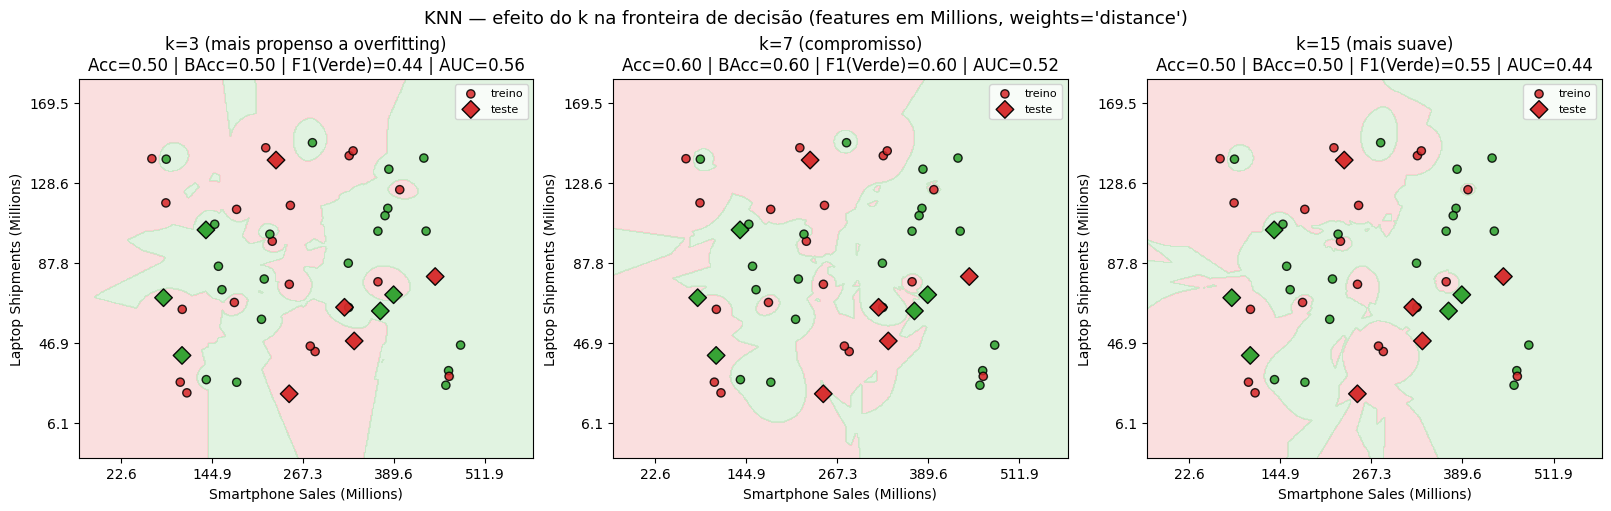

In [ ]:
# ============================================
# KNN: comparação visual de overfitting (k=3,7,15)
# Front. de decisão em 2D: Smartphones (x) vs Laptops (y)
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, roc_curve

# 1) Escolha das duas features para o plano 2D
feat_x = "Smartphone Sales (Millions)"
feat_y = "Laptop Shipments (Millions)"  # troque para "Year" se não tiver laptops

# Garantir que as colunas existem
assert feat_x in X.columns, f"Coluna '{feat_x}' não encontrada em X."
assert feat_y in X.columns, f"Coluna '{feat_y}' não encontrada em X."

# 2) Separar treino/teste apenas com essas duas features
Xtr2 = x_train[[feat_x, feat_y]].to_numpy()
Xte2 = x_test[[feat_x, feat_y]].to_numpy()
ytr2 = y_train.to_numpy()
yte2 = y_test.to_numpy()

# 3) Padronizar
scaler2 = StandardScaler().fit(Xtr2)
Xtr2s = scaler2.transform(Xtr2)
Xte2s = scaler2.transform(Xte2)

def fit_eval_knn(k, p=2, weights="distance"):
    knn = KNeighborsClassifier(n_neighbors=k, p=p, weights=weights)
    knn.fit(Xtr2s, ytr2)
    y_pred = knn.predict(Xte2s)
    y_prob = knn.predict_proba(Xte2s)[:, 1]
    acc  = accuracy_score(yte2, y_pred)
    bacc = balanced_accuracy_score(yte2, y_pred)
    f1v  = f1_score(yte2, y_pred, pos_label=1)
    auc  = roc_auc_score(yte2, y_prob)
    return knn, {"acc": acc, "bacc": bacc, "f1_verde": f1v, "auc": auc}

def plot_boundary(ax, knn, title):
    # Grelha no espaço padronizado
    x_min, x_max = np.r_[Xtr2s[:,0], Xte2s[:,0]].min()-0.8, np.r_[Xtr2s[:,0], Xte2s[:,0]].max()+0.8
    y_min, y_max = np.r_[Xtr2s[:,1], Xte2s[:,1]].min()-0.8, np.r_[Xtr2s[:,1], Xte2s[:,1]].max()+0.8
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap_bg  = ListedColormap(["#f7c6c6", "#c9eac9"])   # fundo: Sujo/Verde
    cmap_pts = ListedColormap(["#d62728", "#2ca02c"])   # pontos

    ax.contourf(xx, yy, Z, alpha=0.55, cmap=cmap_bg)
    ax.scatter(Xtr2s[:,0], Xtr2s[:,1], c=ytr2, cmap=cmap_pts, edgecolor="k", s=35, alpha=0.85, label="treino")
    ax.scatter(Xte2s[:,0], Xte2s[:,1], c=yte2, cmap=cmap_pts, edgecolor="k", s=80, marker="D", alpha=0.95, label="teste")

    # ticks nas escalas originais
    xt = ax.get_xticks()
    yt = ax.get_yticks()
    xt_orig = scaler2.inverse_transform(np.c_[xt, np.zeros_like(xt)])[:,0]
    yt_orig = scaler2.inverse_transform(np.c_[np.zeros_like(yt), yt])[:,1]
    ax.set_xticklabels([f"{v:.1f}" for v in xt_orig])
    ax.set_yticklabels([f"{v:.1f}" for v in yt_orig])

    ax.set_xlabel(feat_x)
    ax.set_ylabel(feat_y)
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8, frameon=True)

# 4) Rodar e plotar k=3,7,15 (p=2 Euclidiana; ponderado por distância)
configs = [(3, "k=3 (mais propenso a overfitting)"),
           (7, "k=7 (compromisso)"),
           (15, "k=15 (mais suave)")]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
for (k, label), ax in zip(configs, axes):
    knn, m = fit_eval_knn(k=k, p=2, weights="distance")
    title = f"{label}\nAcc={m['acc']:.2f} | BAcc={m['bacc']:.2f} | F1(Verde)={m['f1_verde']:.2f} | AUC={m['auc']:.2f}"
    plot_boundary(ax, knn, title)

fig.suptitle("KNN — efeito do k na fronteira de decisão (features em Millions, weights='distance')", fontsize=13)
plt.show()


Abaixo, a nterpretação dos resultados relacionados aos gráficos de fronteira de decisão dos vizinhos quando:

k = 3 (mais propenso a overfitting)
A fronteira de decisão ficou muito recortada, criando várias “ilhas” que seguem de perto pontos individuais.

Vantagem: maior detalhamento local, AUC=0.56 (o mais alto).

Desvantagem: risco de overfitting, ou seja, o modelo memoriza padrões específicos mas perde capacidade de generalizar.

k = 7 (compromisso)
A fronteira suavizou, mas ainda preserva bem a separação entre regiões. Balanced Accuracy=0.60 e F1(Verde)=0.60, indicando melhor equilíbrio entre as classes. Esse valor de k foi o mais estável, reduzindo overfitting sem cair no extremo de simplificação.

k = 15 (mais suave, risco de underfitting)
A fronteira ficou ampla e pouco detalhada, quase ignorando variações locais. Desvantagem: desempenho caiu (AUC=0.44, Balanced Accuracy=0.50).Indica underfitting, ou seja, o modelo simplificou tanto que deixou de capturar diferenças relevantes.


Logo, pode-se dizer que o melhor resultado foi com k=7, pois:

- Equilibrou detalhamento vs generalização;
- Melhorou as métricas de avaliação (Balanced Accuracy e F1 da classe Verde);
- Apresentou uma fronteira de decisão mais coerente.

O que é possível fazer para tornar o modelo mais preciso? Testa-se:
1)Fixar KNN com k≈7–9, comparar Euclidiana vs Manhattan.
2) Criar uma feature agregada (Gadget_Average) e testar se melhora.
3)

Resultados (ordenado por F1_Verde, depois AUC):
 k  p  weights  Accuracy  Balanced_Acc  F1_Verde  F1_Macro  AUC_ROC
 7  1 distance       0.4           0.4  0.571429  0.285714     0.32
 7  2 distance       0.4           0.4  0.571429  0.285714     0.32
 8  1 distance       0.4           0.4  0.571429  0.285714     0.32
 9  1 distance       0.4           0.4  0.571429  0.285714     0.28
 9  2 distance       0.3           0.3  0.461538  0.230769     0.36
 8  2 distance       0.3           0.3  0.461538  0.230769     0.32

=== Melhor KNN ===
 k=7, p=1 (Manhattan), weights=distance
 Accuracy=0.400 | Balanced_Acc=0.400 | F1_Verde=0.571 | F1_Macro=0.286 | AUC=0.320

Relatório de Classificação (melhor KNN):
              precision    recall  f1-score   support

        Sujo       0.00      0.00      0.00         5
       Verde       0.44      0.80      0.57         5

    accuracy                           0.40        10
   macro avg       0.22      0.40      0.29        10
weighted avg       

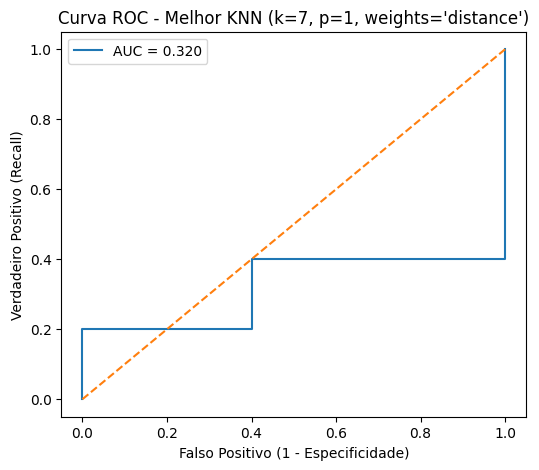

In [ ]:
# ============================================
# KNN com k em {7,8,9} e weights="distance"
# Comparação p=1 (Manhattan) vs p=2 (Euclidiana)
# Seleção pelo F1 da classe 1 (Verde)
# ============================================
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

results = []
best_model = None
best_score = -1
best_info = None

for k in [7, 8, 9]:
    for p in [1, 2]:  # 1=Manhattan, 2=Euclidiana
        pipe = Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k, p=p, weights="distance"))
        ])
        pipe.fit(x_train, y_train)
        y_pred = pipe.predict(x_test)
        y_prob = pipe.predict_proba(x_test)[:, 1]

        acc  = accuracy_score(y_test, y_pred)
        bacc = balanced_accuracy_score(y_test, y_pred)
        f1v  = f1_score(y_test, y_pred, pos_label=1)   # F1 da classe Verde
        f1m  = f1_score(y_test, y_pred, average="macro")
        auc  = roc_auc_score(y_test, y_prob)

        results.append({
            "k": k, "p": p, "weights": "distance",
            "Accuracy": acc, "Balanced_Acc": bacc,
            "F1_Verde": f1v, "F1_Macro": f1m, "AUC_ROC": auc
        })

        if f1v > best_score:
            best_score = f1v
            best_model = pipe
            best_info = (k, p, "distance", acc, bacc, f1v, f1m, auc)

# Tabela de resultados
df_res = pd.DataFrame(results).sort_values(["F1_Verde","AUC_ROC"], ascending=False)
print("Resultados (ordenado por F1_Verde, depois AUC):")
print(df_res.to_string(index=False))

# Melhor configuração
k_best, p_best, w_best, acc, bacc, f1v, f1m, auc = best_info
print(f"\n=== Melhor KNN ===\n k={k_best}, p={p_best} ({'Manhattan' if p_best==1 else 'Euclidiana'}), weights={w_best}")
print(f" Accuracy={acc:.3f} | Balanced_Acc={bacc:.3f} | F1_Verde={f1v:.3f} | F1_Macro={f1m:.3f} | AUC={auc:.3f}")

# Relatório e matriz de confusão do melhor
y_pred_best = best_model.predict(x_test)
y_prob_best = best_model.predict_proba(x_test)[:, 1]
print("\nRelatório de Classificação (melhor KNN):")
print(classification_report(y_test, y_pred_best, target_names=["Sujo","Verde"]))
print("Matriz de Confusão (melhor KNN):")
print(confusion_matrix(y_test, y_pred_best, labels=[0,1]))

# Curva ROC do melhor
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_best):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Falso Positivo (1 - Especificidade)")
plt.ylabel("Verdadeiro Positivo (Recall)")
plt.title(f"Curva ROC - Melhor KNN (k={k_best}, p={p_best}, weights='distance')")
plt.legend()
plt.show()


A primeira tentativa não funciona para o caso (???)

In [ ]:
def preprocess_avg_millions(df):
    df = df.sort_values(["Country", "Year"]).copy()

    # Codificação do país
    le = LabelEncoder()
    df["Country_Code"] = le.fit_transform(df["Country"])

    # Calcular deltas
    df["Delta_Spending"] = df.groupby("Country")["Average Consumer Spending on Gadgets ($)"].diff()
    df["Delta_Ewaste"]   = df.groupby("Country")["E-Waste Generated (Metric Tons)"].diff()

    # Classe alvo (regra: Verde=1 se ΔSpending>0 e ΔEwaste>0, senão Sujo=0)
    def classify_growth(row):
        if pd.notnull(row["Delta_Spending"]) and row["Delta_Spending"] > 0:
            return 1 if row["Delta_Ewaste"] > 0 else 0
        return None

    df["Sustentabilidade"] = df.apply(classify_growth, axis=1)
    df = df.dropna(subset=["Sustentabilidade"]).copy()
    df["Sustentabilidade"] = df["Sustentabilidade"].astype(int)

    # Criar média só das colunas em "Millions"
    df["Gadget_Average"] = df[
        [
            "Smartphone Sales (Millions)",
            "Laptop Shipments (Millions)"
        ]
    ].mean(axis=1)

    # Features finais
    features = ["Gadget_Average", "Country_Code", "Year"]

    X = df[features].copy()
    y = df["Sustentabilidade"].copy()
    return X, y
x, y =  preprocess_avg_millions(df)
x_train, x_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape X:", X.shape)
print("Features:", X.columns.tolist())
print(y.value_counts(normalize=True))


Shape X: (49, 4)
Features: ['Smartphone Sales (Millions)', 'Laptop Shipments (Millions)', 'Country_Code', 'Year']
Sustentabilidade
1    0.530612
0    0.469388
Name: proportion, dtype: float64
